# Figure 4, Part 2: Decision variable prediction

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
%run env_aws.py
%run run.py connect

2025-02-13 17:08:20,763::INFO::settings.py::Setting loglevel to INFO
2025-02-13 17:08:20,764::INFO::settings.py::Setting stores to {}
2025-02-13 17:08:20,765::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-02-13 17:08:20,765::INFO::settings.py::Setting database.misc.create_tables to True
2025-02-13 17:08:20,765::INFO::settings.py::Setting enable_python_native_blobs to True
2025-02-13 17:08:20,766::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-02-13 17:08:20,767::INFO::settings.py::Setting database.user to celia
2025-02-13 17:08:20,767::INFO::settings.py::Setting database.password to celia_mathislab
2025-02-13 17:08:20,914::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-02-13 17:08:21,023::INFO::table.py::could not log event in table ~log
2025-02-13 17:08:21,519::INFO::table.py::could not log event in table ~log
2025-02-13 17:08:21,519::INFO::table.py::could not log event in table ~log
2025-02-13 17:08:21,983::INFO::table.py::could not log event in table ~log
2025-02-13 17:08:21,983::INFO::table.py::could not log event in table ~log
2025-02-13 17:08:22,136::INFO::table.py::could not log event in table ~log
2025-02-13 17:08:22,136::INFO::table.py::could not log event in table ~log
2025-02-13 17:08:22,472::INFO::table.py::could not log event in table ~log
2025-02-13 17:08:22,472::INFO::table.py::could not log event in table ~log
2025-02-13 17:08:22,851::INFO::table.py::could not log event in table ~log
2025-02-13 17:08:22,851::INFO::table.py::could not log event in table ~log


In [5]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils
from vr4mice.analysis import regression

from statsmodels.stats.anova import AnovaRM 
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
style()

save_fig_path =  "notebooks/Paper_figures/Figure_output/"

In [6]:
# See Figure 4 B-E notebook to see how the data was generated
niell_data = pd.read_pickle("big_df_contrast_multi_niell.pkl")
mathis_data = pd.read_pickle("big_df_contrast_multi.pkl")
big_df = pd.concat([niell_data, mathis_data]).reset_index(drop=True)

In [7]:
big_df = big_df [big_df.iti ==0.0]
#big_df = big_df [big_df.trial_rewarded == 1.0]
# only rewarded trials doesn't make sense if we keep trial_rewarded as a feature in the model

In [8]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
interpolated_j_shaped = utils.interpolate_j_shaped(big_df, box_df, n_points=500)

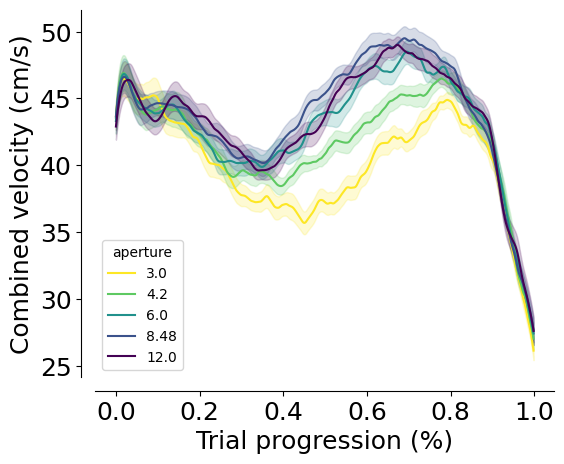

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

label = "velocity"
sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y="velocity",
        palette=plotting.colors_multi_aperture,
        hue="aperture",
        errorbar="se",
        ax=ax,
    )

sns.despine(offset=10)
ax.set_xlabel("Trial progression (%)")
ax.set_ylabel("Combined velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "multi_occluder_velocity.svg", transparent=False)

2025-02-13 17:10:07,928::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:10:07,928::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:10:07,934::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:10:07,934::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:10:08,020::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=1.1238607067298458, pvalue=0.27134199668755354, df=26)
3.0-6.0: TtestResult(statistic=0.8849559304120269, pvalue=0.3842916486982493, df=26)
3.0-8.48: TtestResult(statistic=2.1113628804327877, pvalue=0.04450961229435419, df=26)
4.2-6.0: TtestResult(statistic=0.06906225201395146, pvalue=0.9454684877320492, df=26)
4.2-8.48: TtestResult(statistic=1.0819400308348264, pvalue=0.2892122680081895, df=26)
6.0-8.48: TtestResult(statistic=0.9863839848653371, pvalue=0.3330356906534394, df=26)
12.0-3.0: TtestResult(statistic=-2.304930313247168, pvalue=0.029409243661365016, df=26)
12.0-4.2: TtestResult(statistic=-1.8819024701341234, pvalue=0.07108916253982966, df=26)
12.0-6.0: TtestResult(statistic=-2.0373416432815583, pvalue=0.05191406967308131, df=26)
12.0-8.48: TtestResult(statistic=-0.9837179322842869, pvalue=0.33432041685471026, df=26)


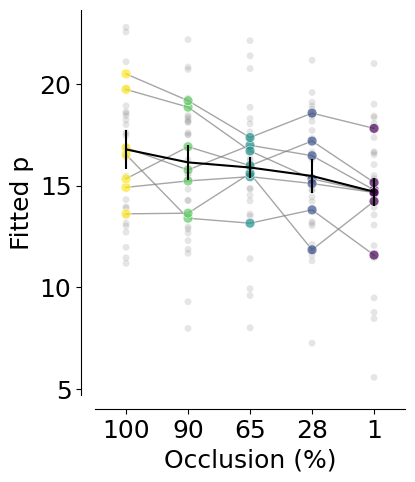

In [10]:
# fitted p of the optimal L-p curve

big_df["optimal_p"] = analysis.get_optimal_p(big_df)
j_shaped = analysis.get_jshaped_trials(big_df)


fig,ax = plt.subplots(1,1, figsize = (4,5))

counts = j_shaped[j_shaped.trial_rewarded==1].groupby(["mouse_name", "dataset", "aperture"], as_index=False).optimal_p.mean()

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_multi_aperture,
)
ax.invert_xaxis()

ax.set_xlabel("Occlusion (%)")
ax.set_ylabel("Fitted p")
ax.set_xlim(-.5,4.5)
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
plt.legend([],[], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")

In [11]:
interpolated_j_shaped["aperture"] = interpolated_j_shaped["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_j_shaped, label=regression.model_labels, per_mouse=True)

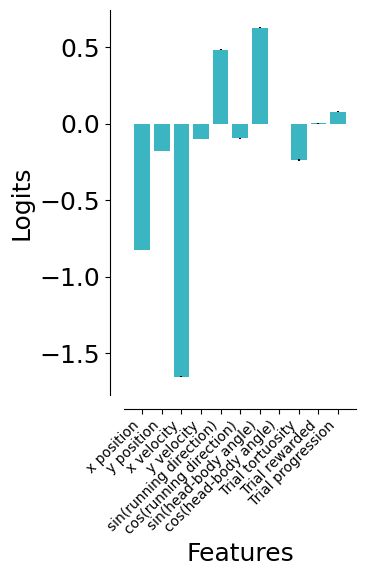

In [12]:
# Logits of the regression
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
ax.bar(
    regression.model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#3AB5C1"
)
sns.despine(offset=10, ax=ax)

ax.set_xticks(np.arange(len(regression.model_labels))) 
ax.set_xticklabels(regression.clean_model_labels, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Logits")
ax.set_xlabel("Features")

plt.savefig(save_fig_path + "multi_occluder_model_logits.svg", transparent=False)

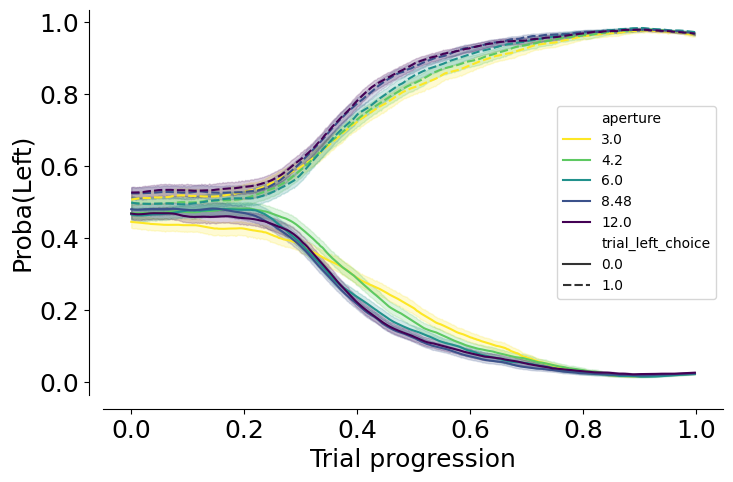

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.lineplot(
        data=df_model,
        x="trial_length",
        y="proba_left",
        hue="aperture",
        style="trial_left_choice", 
        palette= plotting.colors_multi_aperture,
        sort=False, alpha=1, ax=ax
    )
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")
sns.despine(offset = 10)
plt.savefig(save_fig_path + "multi_dynamic_decision_variable_mean.svg", transparent=True)

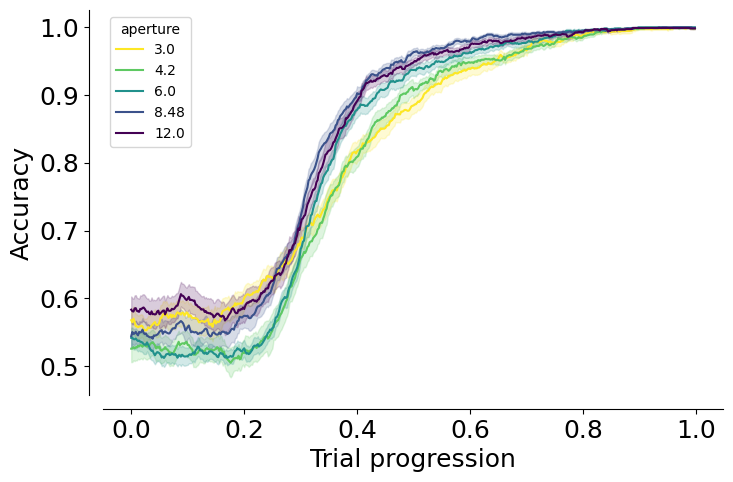

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

mean_mouse = df_model.groupby(["dataset", "aperture", "trial_length"]).mean(
    numeric_only=True
)

mean_mouse_per_choice = df_model.groupby(
    ["dataset", "trial_left_choice", "aperture", "trial_length"]
).mean(numeric_only=True)

# Accuracy
sns.lineplot(
    ax=ax,
    data=mean_mouse,
    y="accuracy",
    x="trial_length",
    hue="aperture",
    palette=plotting.colors_multi_aperture,
    errorbar="se",
)
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Accuracy")
#percentile = np.percentile(mean_mouse_model_shuff.accuracy, 95)
plt.savefig(save_fig_path + "multi_occluder_model_accuracy.svg", transparent=False)


In [18]:
df_model["trial_length_bin"] = pd.cut(df_model["trial_length"], bins=50)  # Adjust bins as needed
df_anova = df_model.groupby(["dataset", "aperture", "trial_length_bin"], as_index=False)["accuracy"].mean()

print(AnovaRM(data=df_anova, depvar="accuracy", 
              subject="dataset", within=["aperture", "trial_length_bin"]).fit())

                            Anova
                           F Value   Num DF    Den DF  Pr > F
-------------------------------------------------------------
aperture                     7.9239   4.0000  104.0000 0.0000
trial_length_bin          1077.1230  49.0000 1274.0000 0.0000
aperture:trial_length_bin    4.6138 196.0000 5096.0000 0.0000



In [14]:
df_model ["session"] = df_model ["dataset"]
df_model ["trial_L_choice"] = df_model ["trial_left_choice"]
decision_points = regression.find_decision_point(df_model, threshold_uncertainty=0.3)

2025-02-13 17:13:03,433::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:13:03,433::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:13:03,438::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:13:03,438::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2025-02-13 17:13:03,535::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:13:03,535::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:13:03,540::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:13:03,540::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 17:13:03,558::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=1.7328912144320416, pvalue=0.09496232586755171, df=26)
3.0-6.0: TtestResult(statistic=4.824080213378687, pvalue=5.346670308647153e-05, df=26)
3.0-8.48: TtestResult(statistic=8.35618117136474, pvalue=7.740829554017705e-09, df=26)
4.2-6.0: TtestResult(statistic=3.3577520439411934, pvalue=0.002429974624890526, df=26)
4.2-8.48: TtestResult(statistic=5.77980518106064, pvalue=4.352587379432178e-06, df=26)
6.0-8.48: TtestResult(statistic=5.5961531583158015, pvalue=7.021211100628037e-06, df=26)
12.0-3.0: TtestResult(statistic=-10.087967478675582, pvalue=1.7660715347115918e-10, df=26)
12.0-4.2: TtestResult(statistic=-8.119806012146432, pvalue=1.33711082594209e-08, df=26)
12.0-6.0: TtestResult(statistic=-8.245080254687736, pvalue=9.999089348091986e-09, df=26)
12.0-8.48: TtestResult(statistic=-1.9429708651794206, pvalue=0.06292181848559912, df=26)


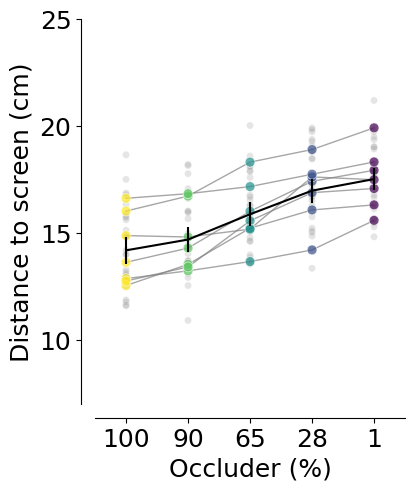

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
_ = plotting.pairplot_average_decision_point(decision_points, 
                                                 label_parameter="y",  
                                                 ax=ax, 
                                                 cmap=plotting.colors_multi_aperture,
                                                 per_mouse=True)
ax.set_ylim(7,25)
ax.set_xlim(-.5,4.5)
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
plt.legend([],[], frameon=False)
sns.despine(offset=10)

plt.savefig(save_fig_path + "multi_occluder_decision_points.svg", transparent=True)

In [19]:
decision_points = decision_points.groupby(["dataset", "aperture"], as_index=False)["y"].mean()
anova_rm = AnovaRM(decision_points, depvar='y', subject='dataset', within=['aperture'])

anova_results = anova_rm.fit()
anova_table = anova_results.summary()
print(anova_table)

                 Anova
         F Value Num DF  Den DF  Pr > F
---------------------------------------
aperture 42.5372 4.0000 104.0000 0.0000



In [20]:
# trials_by_time = interpolated_j_shaped.groupby(["aperture", "trial_step", "trial_left_choice"], as_index=False)[["x", "y"]].mean()

In [21]:
# sns.lineplot(trials_by_time, 
#              x="x", 
#              y="y", 
#              hue="aperture", 
#              style="trial_left_choice", 
#              palette=plotting.colors_multi_aperture, 
#              sort=False, 
#              alpha=1)